In [ ]:
import pandas as pd
import re
import emoji
import numpy as np
import swifter
import nltk
d=pd.read_csv("raw_tweets_text.csv",nrows=2000000)
d=d.drop_duplicates(subset="text")
d.head()

,id,text
0,758014713804587008,RT @polarcomic: And surprise! the #RegularShow...
1,758014717990428672,RT @SweetBabyBellB: My unproblematic fav who k...
2,758014646716665857,RT @WhyLarryIsReal: I mean we know harry isn't...
3,758014655071526912,"RT @Eastbay: She's ready, resilient, and on ou..."
4,758014642526429184,RT @SheeeRatchet: find someone who loves you a...


In [41]:
# Example slang dictionary
slang_dict = {
    "gr8": "great",
    "lol": "laugh",
    "omg": "oh my god",
    "btw": "by the way",
    "idk": "I don't know",
    "smh": "shaking my head"
}

# Sarcasm triggers
sarcasm_triggers = ["yeah right", "sure", "as if", "lol", "totally", "not really"]

def has_emoji(text):
    if not isinstance(text,str):
        return False
    return emoji.emoji_count(text)>0
#Clean text
def clean_tweet(text):
    if not isinstance(text,str):
        return ""
    text=text.lower() #lower text

    #Transform emoticons to tokens
    emoticon_dict = {":)": "emoji_smile", ":-)": "emoji_smile",
                     ":(": "emoji_sad", ":-(": "emoji_sad",
                     ":D": "emoji_laugh", ";)": "emoji_wink"}
    
    for emo, token in emoticon_dict.items():
        text=text.replace(emo, f" {token} ")
        
    for slang,word in slang_dict.items():
        text=re.sub(rf"\b{slang}\b",word,text)

    text=re.sub(r"https?://\S+|www\.\S+","",text) #remove URLs
    text=re.sub(r"@\w+","",text) #remove mention
    text=re.sub(r"\brt\b","",text) #remove retweet
    text=re.sub(r"#(\w+)",r"\1",text) # remove hashtag
    text=re.sub(r"[\n\t]","",text) # remove newline and tab
    text=re.sub(r"[^\w\s]"," ",text)
    text=re.sub(r"\d+","",text) #remove numbers
    text=re.sub(r"(.)\1{2,}",r"\1\1",text) #limit repeated characters to 2
    return " ".join(text.split()).strip()

#Transform emoji in token
def demojize_text(text):
    text=emoji.demojize(text,language='en')
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)
    return text.strip()

def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

df_tweet_with_emojis=d[d["text"].swifter.apply(has_emoji)].copy()

df_tweet_with_emojis["emojis"]=df_tweet_with_emojis["text"].swifter.apply(extract_emojis)
df_tweet_with_emojis["demojize"]=df_tweet_with_emojis["text"].swifter.apply(demojize_text)
df_tweet_with_emojis["text_clean"]=df_tweet_with_emojis["text"].swifter.apply(clean_tweet)

df_tweet_with_emojis.sample(10)

Pandas Apply:   9%|▉         | 294979/3176206 [00:18<02:56, 16368.33it/s]


KeyboardInterrupt: 

In [ ]:
import contractions
import string
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords,wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

#Setup NLTK
tokenizer=TweetTokenizer()
sentence_breakers = {'.', '!', '?', ';', ':','but','however','although','though','even though','whereas'}
negation_words = {'not','no','never','neither','nor',
                  "can't","cannot","don't","didn't","doesn't","isn't","wasn't","weren't","ain't"}
stopwords_set=set(stopwords.words('english'))-negation_words
lemmatizer=WordNetLemmatizer()

sentence_breakers = {'.', '!', '?', ';', ':','but','however','although','though','even though','whereas'}

NEG=3 #Number of words after which negation effect ends

#Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'): 
        return wordnet.NOUN
    elif tag.startswith('R'): 
        return wordnet.ADV
    else:
        return wordnet.NOUN #Default

def lemmatize_tokens(tokens):
    tagged_tokens=pos_tag(tokens)
    final=[]
    negation=0
    for word, tag in tagged_tokens:
        word_lower=word.lower()

        if word_lower in sentence_breakers or word in string.punctuation:
            negation=0
            final.append(word)
            continue
        if word_lower.startswith("emoji_"):
            prefix="NOT_" if negation>0 else ""
            final.append(prefix+word_lower)
            if negation>0:
                negation-=1
            continue
        
        if word.isalpha() and (word_lower not in stopwords_set or word_lower in negation_words):
            lemma=lemmatizer.lemmatize(word_lower,get_wordnet_pos(tag))
            if word_lower in negation_words:
                negation=NEG
                final.append(lemma)
            elif negation>0:
                final.append("NOT_"+lemma)
                negation-=1
            else:
                final.append(lemma)
        else:
            final.append(word_lower)
                    
    return final

def tokenize_lemmatize(text):
    if not isinstance(text,str):
        return []
    text=contractions.fix(text)
    tokens=tokenizer.tokenize(text)
    return lemmatize_tokens(tokens)

df_tweet_with_emojis["final_tokens"]=df_tweet_with_emojis["text_clean"].swifter.apply(tokenize_lemmatize)
df_tweet_with_emojis.sample(10)


Pandas Apply: 100%|██████████| 186150/186150 [01:08<00:00, 2731.05it/s]


,id,text,emojis,demojize,text_clean,final_tokens
672537,769350810211749888,RT @jordyn_wieber: It was awesome talking to @...,[💗],RT @jordyn_wieber: It was awesome talking to @...,it was awesome talking to today love the gymnasts,"[it, was, awesome, talk, to, today, love, the,..."
148399,758227889317879808,RT @Life_on_Planet: Why #Vegan ➡️Dairy calves ...,"[➡, 💔]",RT @Life_on_Planet: Why #Vegan emoji_right_ar...,why vegan dairy calves stolen from their mothe...,"[why, vegan, dairy, calf, steal, from, their, ..."
732444,769500752414924800,Would anyone fu@k this😬 https://t.co/U4FHg6b5vJ,[😬],Would anyone fu@k this emoji_grimacing_face ht...,would anyone fu this,"[would, anyone, fu, this]"
478369,768839348389228544,RT @DanielRocksLGNA: Witness the world premier...,[😊],RT @DanielRocksLGNA: Witness the world premier...,witness the world premiere of s biggest cinema...,"[witness, the, world, premiere, of, s, big, ci..."
1103457,782504407602569216,"Come join me, or you'll be left behind #BIGOLI...","[👑, ✨, 🍗, 🍩]","Come join me, or you'll be left behind #BIGOLI...",come join me or you ll be left behind bigolive...,"[come, join, me, or, you, ll, be, leave, behin..."
427272,768674508077019136,RT @KaylenMedina: Tb with my Gramps 💗 https://...,[💗],RT @KaylenMedina: Tb with my Gramps emoji_gro...,tb with my gramps,"[tb, with, my, gramps]"
961586,781507102791663616,Palms and a blue sky 🌴🌴 https://t.co/lA8TaSWEMA,"[🌴, 🌴]",Palms and a blue sky emoji_palm_tree emoji_pa...,palms and a blue sky,"[palm, and, a, blue, sky]"
402583,768623148833075200,Wet girl waiting📣 https://t.co/IkFLGexXmz#milf...,[📣],Wet girl waiting emoji_megaphone https://t.co/...,wet girl waiting vintage massage milf lesbian ...,"[wet, girl, wait, vintage, massage, milf, lesb..."
2536,758018069260185600,The ONLY move Saturday 😈#BBLU5 at OPERA 🙌🏾http...,"[😈, 🙌, 🏾]",The ONLY move Saturday emoji_smiling_face_wit...,the only move saturday bblu at opera,"[the, only, move, saturday, bblu, at, opera]"
260472,768251093058883585,Taeyeon will be in the September issue of BEAU...,[😍],Taeyeon will be in the September issue of BEAU...,taeyeon will be in the september issue of beau...,"[taeyeon, will, be, in, the, september, issue,..."


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB,MultinomialNB
from sklearn.metrics import classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

emoji_db=pd.read_csv("Emoji_Sentiment.csv",encoding="utf-8") #Dataset with emoji sentiment scores
emoji_db["score"]=(emoji_db["Positive"]-emoji_db["Negative"])/(emoji_db["Positive"]+emoji_db["Negative"]+emoji_db["Neutral"]) #Calculate sentiment score as normalized difference
emoji_lookup=dict(zip(emoji_db["Emoji"],emoji_db["score"]))

sia=SentimentIntensityAnalyzer()#Inizialize VADER sentiment analyzer

def get_score_emoji(emoji_list):
    if not emoji_list:
        return 0.0
    score={emoji_lookup.get(e,0.0) for e in emoji_list}

    return sum(score)/len(score)

#Function to convert VADER compound score to labels
def vader_label(text_score,emoji_score,alpha=0.8, margin=0.05):
    final_score=text_score+alpha*emoji_score
    if final_score>margin:
        return "Positive"
    else:
        return "Negative"
    
#Calculate emoji_score using VADER
df_tweet_with_emojis["emoji_score"]=df_tweet_with_emojis["emojis"].swifter.apply(get_score_emoji)
df_tweet_with_emojis["text_score"]=df_tweet_with_emojis["text_clean"].swifter.apply(lambda x: sia.polarity_scores(str(x))['compound'])

df_tweet_with_emojis["sentiment"] = df_tweet_with_emojis.swifter.apply(lambda row: vader_label(row["text_score"], row["emoji_score"]), axis=1)

print("Distribuzione sentiment:", df_tweet_with_emojis["sentiment"].value_counts())

#Prepare Features & Target
X_test=df_tweet_with_emojis["final_tokens"].apply(lambda t: " ".join(t)) #Join tokens into string
X_extra=df_tweet_with_emojis["emoji_score"].values.reshape(-1,1) #Emoji score as numeric feature
y=df_tweet_with_emojis["sentiment"] #Target sentiment

#Train/test split
X_train_text, X_test_text, X_train_extra,X_test_extra,y_train,y_test=train_test_split(X_test,X_extra,y,test_size=0.2,random_state=42,stratify=y)

#TF-IDF
tfidf=TfidfVectorizer(ngram_range=(1,3),min_df=5,max_df=0.8,sublinear_tf=True,max_features=50000) #Consider unigrams to n-grams, ignore rare terms (min_df), ignore very common terms (max_df) and 
#apply logarithmic scaling to term frequency
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)

scaler=StandardScaler()

X_train_extra_scaled=scaler.fit_transform(X_train_extra)
X_test_extra_scaled=scaler.transform(X_test_extra)
#Union of TF-IDF features and emoji_score
X_train_final=hstack([X_train_tfidf,X_train_extra_scaled])
X_test_final=hstack([X_test_tfidf,X_test_extra_scaled])

df_tweet_with_emojis.sample(10)

Pandas Apply: 100%|██████████| 186150/186150 [00:01<00:00, 173265.92it/s]


Distribuzione sentiment: sentiment
Positive    160302
Negative     25848
Name: count, dtype: int64


,id,text,emojis,demojize,text_clean,final_tokens,emoji_score,text_score,sentiment
995730,781719057741512705,“@EdHutchings: A magical day exploring Quito O...,"[😍, 😌]",“@EdHutchings: A magical day exploring Quito O...,a magical day exploring quito old town courtes...,"[a, magical, day, explore, quito, old, town, c...",0.581074,0.7351,Positive
392854,768603771144331265,RT @DerickPauls: https://t.co/O1tt1r2XzZ via @...,"[❤, 🙏]",RT @DerickPauls: https://t.co/O1tt1r2XzZ via @...,via angel by robbie williams of my best songs ...,"[via, angel, by, robbie, williams, of, my, bes...",0.581945,0.7964,Positive
1311377,784112419882708992,Cassette Loc celebrating #NationalPoetryDay wi...,[😘],Cassette Loc celebrating #NationalPoetryDay wi...,cassette loc celebrating nationalpoetryday wit...,"[cassette, loc, celebrate, nationalpoetryday, ...",0.701754,0.5719,Positive
1039124,782003708381032448,Happy Birthday to me 🙊🎉🎂 https://t.co/BKW81zVr11,"[🙊, 🎉, 🎂]",Happy Birthday to me :speak-no-evil_monkey: em...,happy birthday to me,"[happy, birthday, to, me]",0.607379,0.5719,Positive
789501,780362691147816960,❤#GiftCard #Coupon RARE 2006 Starbucks Spring ...,[❤],emoji_red_heart#GiftCard #Coupon RARE 2006 Sta...,giftcard coupon rare starbucks spring lollipop...,"[giftcard, coupon, rare, starbucks, spring, lo...",0.746087,0.4404,Positive
260583,768251252467757056,Haley and I's old tbh😂😭 came a long way😂🙌🏼 #Dr...,"[😂, 😭, 😂, 🙌, 🏼]",Haley and I's old tbh emoji_face_with_tears_of...,haley and i s old tbh came a long way dreamsdo...,"[haley, and, i, s, old, to, be, honest, come, ...",0.172004,0.0000,Positive
1229322,783539767363371008,LifeStraw® Community is designed to provide sa...,[®],LifeStraw emoji_registered Community is design...,lifestraw community is designed to provide saf...,"[lifestraw, community, is, design, to, provide...",0.284672,0.4404,Positive
271681,768274375657127936,RT @kardashhumor: Saint is literally the 👶🏽 em...,"[👶, 🏽, 😍, 😭]",RT @kardashhumor: Saint is literally the emoj...,saint is literally the emoji,"[saint, is, literally, the, emoji]",0.258119,0.0000,Positive
933451,781294359283052544,Joe with Alfie in Marcus' snapchat | 👻:marcusb...,[👻],Joe with Alfie in Marcus' snapchat | emoji_gh...,joe with alfie in marcus snapchat marcusbutler,"[joe, with, alfie, in, marcus, snapchat, marcu...",0.232143,0.0000,Positive
678987,769365293168730112,everything looks perfect Qiannie ♥ https://t.c...,[♥],everything looks perfect Qiannie emoji_heart_...,everything looks perfect qiannie,"[everything, look, perfect, qiannie]",0.657615,0.5719,Positive


In [ ]:
#Test usign MultinomialNB - Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Train Multinomial Naive Bayes classifier with Smoothing Laplace (alpha=1)
model=MultinomialNB(alpha=1)
model.fit(X_train_final,y_train)
y_predMultinomial=model.predict(X_test_final) #Predict and test

print(f"Global Accuracy with MultinomialNB: {accuracy_score(y_test,y_predMultinomial):.2f}\n")
print(classification_report(y_test,y_predMultinomial))
cm=confusion_matrix(y_test,y_predMultinomial,labels=["Positive","Negative"])
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Negative"],yticklabels=["Positive","Negative"])
plt.title("Confusion Matrix with MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ValueError: Negative values in data passed to MultinomialNB (input X).

In [ ]:
#Test using ComplementNB
model2=ComplementNB(alpha=1) #Using Laplace smoothing
model2.fit(X_train_final,y_train)
y_predComplement=model2.predict(X_test_final)
print(f"Global Accuracy with ComplementNB: {accuracy_score(y_test,y_predComplement):.2f}\n")
print(classification_report(y_test,y_predComplement))

cmw=confusion_matrix(y_test,y_predComplement,labels=["Positive","Negative"])
sns.heatmap(cmw,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Negative"],yticklabels=["Positive","Negative"])
plt.title("Confusion Matrix with ComplementNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ValueError: Negative values in data passed to ComplementNB (input X).

Global Accuracy with LogisticRegression: 0.91

              precision    recall  f1-score   support

    Negative       0.61      0.92      0.73      5170
    Positive       0.99      0.91      0.94     32060

    accuracy                           0.91     37230
   macro avg       0.80      0.91      0.84     37230
weighted avg       0.93      0.91      0.91     37230



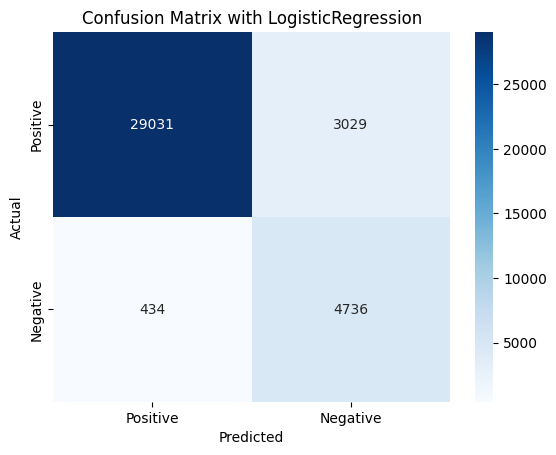

In [ ]:
#Test using LogisticRegression
from sklearn.linear_model import LogisticRegression

modelLogistic=LogisticRegression(max_iter=3000,solver='liblinear',class_weight='balanced',C=0.5)
modelLogistic.fit(X_train_final,y_train)

y_predRegression=modelLogistic.predict(X_test_final)

print(f"Global Accuracy with LogisticRegression: {accuracy_score(y_test,y_predRegression):.2f}\n")
print(classification_report(y_test,y_predRegression))

cmr=confusion_matrix(y_test,y_predRegression,labels=["Positive","Negative"])
sns.heatmap(cmr,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Negative"],yticklabels=["Positive","Negative"])
plt.title("Confusion Matrix with LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()